## Linear data creation

### AIM
* To construct a synthetic dataset with a known causal effect
* Specify a causal model containing confounders, instruments and effect modifiers. 
* Display a graph explaining this causal relationship 

### Method
* Importing the required packages and ensuring the packages are compatible.
Packages used:
+ DoWhy - setting up causal graph
+ e - for drawing causal graph

### Resources
+ d
* Defining data generation parameters like sample size, causal effect, confounders, instruments and effect modifiers.
* Extracted a data frame from this.

## Code setup

In [1]:
import numpy as np  # generate data
import pandas as pd  # display data nicely
import os  # save files

# Update some functions in networkx v3.5 that are incompatible
# with this version of DoWhy v0.8.
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator

import dowhy
from dowhy import CausalModel

import matplotlib.pyplot as plt

## Built-in linear dataset generator

In [2]:
import dowhy.datasets

In [3]:
data = dowhy.datasets.linear_dataset(
    beta=10,  # true causal effect
    num_common_causes=3,
    num_instruments=1,
    num_effect_modifiers=1,
    num_samples=5000,
    treatment_is_binary=True,
    stddev_treatment_noise=10,
    num_discrete_common_causes=1
    )

ValueError: setting an array element with a sequence.

In [ ]:
df = data["df"]

Explanation of which generated variable names are which types of variable:

In [ ]:
name_keys = [k for k in data.keys() if 'name' in k]

for k in name_keys:
    print(f'| {k:>30s} | {str(data[k]):30s} |')

|                 treatment_name | ['v0']                         |
|                   outcome_name | y                              |
|            common_causes_names | ['W0', 'W1', 'W2']             |
|               instrument_names | ['Z0']                         |
|          effect_modifier_names | ['X0']                         |
|      frontdoor_variables_names | []                             |


View the graph of the data:

In [ ]:
# With graph
model = CausalModel(
    data = df,
    treatment=data["treatment_name"],
    outcome=data["outcome_name"],
    graph=data["gml_graph"]
    )

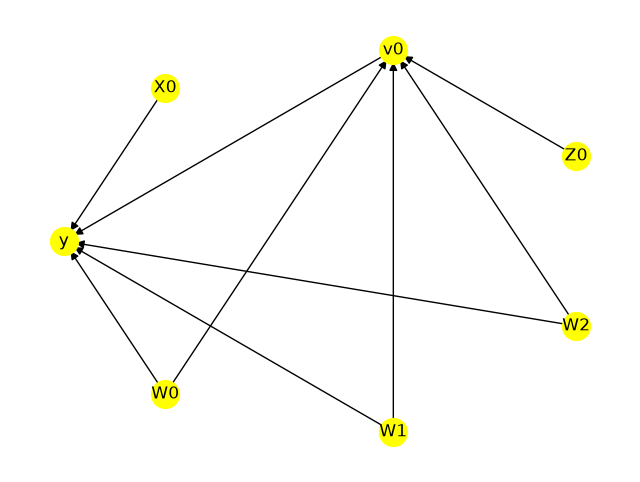

In [ ]:
model.view_model()

Pick out the average treatment effect:

In [ ]:
data['ate']

Check the generated data:

In [ ]:
df

,X0,Z0,W0,W1,W2,v0,y
0,2.127813,0.0,0.203670,0.187712,2,38.229658,540.984432
1,-0.933749,1.0,-0.947498,-0.716778,1,-0.902762,-7.643955
2,0.506173,1.0,-1.755276,1.130864,0,7.726084,84.233315
3,-1.194712,1.0,0.818484,-0.561489,1,6.189908,52.487823
4,1.760746,1.0,-1.069134,0.929992,0,17.347018,230.153226
...,...,...,...,...,...,...,...
4995,1.111986,0.0,-0.672602,0.691109,0,16.774416,202.706376
4996,0.606274,1.0,-1.218579,0.321143,0,16.895057,186.116720
4997,1.360330,1.0,0.257428,0.743741,0,24.930326,314.478989
4998,-0.284454,0.0,-1.029673,-1.327077,2,8.188546,79.521244
